# 12 — Síntesis del EDA

Última etapa: agregar, comparar y escribir el reporte. Antes de cualquier cifra,
el alcance, porque condiciona todo lo que sigue.

> **Este análisis cubre la justicia NO penal.** El estrato
> `tipo_elemento_analitico == "proceso"` contiene solo materias no penales. Los
> cuadros penales del Anuario publican otro juego de columnas y **no publican
> `resueltas`**, así que las fórmulas de CEJA no se les pueden aplicar tal cual.
> Ninguna cifra de acá debe presentarse como "el sistema judicial boliviano".

In [1]:
# --- Arranque -------------------------------------------------------------
# Define __file__ apuntando al script original para que las rutas del proyecto
# resuelvan igual que al correr `python src/analysis/<script>.py`.
import os, sys
from pathlib import Path

RAIZ_PROYECTO = Path.cwd().resolve()
while not (RAIZ_PROYECTO / "src" / "comun.py").exists():
    if RAIZ_PROYECTO.parent == RAIZ_PROYECTO:
        raise RuntimeError("Abrí el notebook desde dentro del repositorio.")
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent

__file__ = str(RAIZ_PROYECTO / "src" / "analysis" / "12_reporte_eda.py")
os.chdir(RAIZ_PROYECTO)
sys.path.insert(0, str(RAIZ_PROYECTO / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# Paleta categórica validada (separación CVD ΔE 9,1; contraste bajo en verde y
# ámbar, por eso todos los gráficos llevan el valor escrito encima).
AZUL, NARANJA, VERDE, AMBAR = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TINTA, TINTA_2, RULE = "#15202a", "#56606b", "#d9d6ce"
RAMPA_AZUL = ["#eaf2fd", "#b7d3f6", "#6da7ec", "#2a78d6", "#1c5cab", "#0d366b"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 9.5, "axes.labelcolor": TINTA_2,
    "axes.edgecolor": RULE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.55, "grid.color": RULE,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False,
})

import textwrap

def envolver(texto, ancho=17):
    """Parte un rótulo largo en varias líneas en vez de truncarlo."""
    return textwrap.fill(str(texto), ancho)

def etiquetar_barh(ax, valores, fmt="{:,.0f}", dx=None):
    """Escribe el valor al final de cada barra horizontal."""
    dx = dx if dx is not None else max(valores) * 0.012
    for i, v in enumerate(valores):
        ax.text(v + dx, i, fmt.format(v), va="center", fontsize=9,
                fontweight="bold", color=TINTA)

print("raíz:", RAIZ_PROYECTO)

raíz: C:\maxi\u\anal\congestion-judicial-bolivia


In [2]:
DATA = RAIZ_PROYECTO / "data/curated/features/dataset_analitico_curado.parquet"
OUT_TABLES = RAIZ_PROYECTO / "reports/tables"
OUT_FIG = RAIZ_PROYECTO / "reports/figures"
OUT_DOCS = RAIZ_PROYECTO / "docs"
for d in (OUT_TABLES, OUT_FIG, OUT_DOCS):
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA)
proc = df[df["tipo_elemento_analitico"] == "proceso"].copy()

cobertura = proc["atendidas"].sum() / df["atendidas"].sum()
print(f"universo del dataset analítico : {len(df):,} filas | "
      f"{int(df['atendidas'].sum()):,} causas atendidas")
print(f"estrato analizado (proceso)    : {len(proc):,} filas | "
      f"{int(proc['atendidas'].sum()):,} causas atendidas")
print(f"cobertura                      : {cobertura:.1%}")
print("\nmaterias fuera del análisis:")
for m in sorted(df.loc[df['tipo_elemento_analitico'] != 'proceso', 'materia_homologada'].dropna().unique()):
    print("  -", m)

universo del dataset analítico : 1,997 filas | 706,485 causas atendidas
estrato analizado (proceso)    : 1,655 filas | 335,472 causas atendidas
cobertura                      : 47.5%

materias fuera del análisis:
  - Instrucción Anticorrupción
  - Instrucción Contra la Violencia hacia las Mujeres
  - Instrucción Penal
  - SENTENCIA ANTICORRUPCIÓN
  - Sentencia Penal
  - TRIBUNAL DE SENTENCIA ANTICORRUPCIÓN
  - TRIBUNAL DE SENTENCIA CONTRA LA VIOLENCIA HACIA LA MUJER
  - Tribunales de Sentencia Penal


## 1. El trazo grueso

Cinco cifras que resumen la gestión 2023 en la justicia no penal.

In [3]:
tot_ing = int(proc["ingresos_totales"].sum())
tot_at = int(proc["atendidas"].sum())
tot_res = int(proc["resueltas"].sum())
tot_pend = int(proc["pendientes_fin"].sum())
cr_glob = tot_res / tot_ing
tc_glob = tot_at / tot_res
dur_glob = tot_pend / tot_res * 365

for rot, val in [("Causas ingresadas", f"{tot_ing:,}"),
                 ("Causas atendidas", f"{tot_at:,}"),
                 ("Causas resueltas", f"{tot_res:,}"),
                 ("Stock pendiente al cierre", f"{tot_pend:,}"),
                 ("Clearance rate global", f"{cr_glob:.1%}"),
                 ("Tasa de congestión ponderada", f"{tc_glob:.2f}"),
                 ("Duración estimada ponderada", f"{dur_glob:,.0f} días")]:
    print(f"  {rot:<30} {val:>14}")

  Causas ingresadas                     250,871
  Causas atendidas                      335,472
  Causas resueltas                      209,197
  Stock pendiente al cierre             126,065
  Clearance rate global                   83.4%
  Tasa de congestión ponderada             1.60
  Duración estimada ponderada          220 días


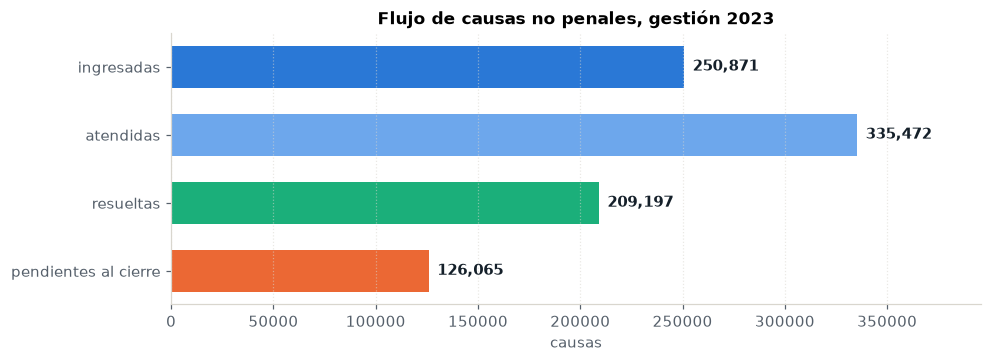

In [4]:
# El embudo: de lo que entró a lo que quedó abierto.
etapas = ["ingresadas", "atendidas", "resueltas", "pendientes al cierre"]
valores = [tot_ing, tot_at, tot_res, tot_pend]
colores_e = [AZUL, "#6da7ec", VERDE, NARANJA]

fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.barh(etapas[::-1], valores[::-1], color=colores_e[::-1], height=.62)
for i, v in enumerate(valores[::-1]):
    ax.text(v + max(valores) * .012, i, f"{v:,}", va="center", fontsize=9.5,
            fontweight="bold", color=TINTA)
ax.set_xlim(0, max(valores) * 1.18)
ax.set_xlabel("causas")
ax.set_title("Flujo de causas no penales, gestión 2023")
ax.grid(axis="y", visible=False)
plt.show()

`atendidas` es mayor que `ingresadas` porque incluye el stock que venía del año
anterior. Esa es justamente la definición del numerador de la tasa de
congestión.

## 2. Por materia

In [5]:
materias = proc.groupby("materia_homologada").agg(
    total_procesos=("tipo_proceso", "count"),
    ingresos_totales=("ingresos_totales", "sum"),
    nuevas_ingresadas=("nuevas_ingresadas", "sum"),
    atendidas=("atendidas", "sum"),
    resueltas=("resueltas", "sum"),
    pendientes_fin=("pendientes_fin", "sum"),
    cr_mediana=("tasa_resolucion", "median"),
    congestion_mediana=("tasa_congestion", "median"),
    duracion_dias_mediana=("duracion_estimada_dias", "median"),
    n_outliers_carga=("es_outlier_carga_iqr", "sum"),
    n_outliers_congestion=("es_outlier_congestion_iqr", "sum"),
).reset_index()
materias["cr_ponderado"] = materias["resueltas"] / materias["ingresos_totales"].replace(0, np.nan)
materias["congestion_ponderada"] = materias["atendidas"] / materias["resueltas"].replace(0, np.nan)
materias["duracion_dias_ponderada"] = (materias["pendientes_fin"] / materias["resueltas"].replace(0, np.nan)) * 365
materias = materias.sort_values("atendidas", ascending=False)
materias.round(2)

,materia_homologada,total_procesos,ingresos_totales,nuevas_ingresadas,atendidas,resueltas,pendientes_fin,cr_mediana,congestion_mediana,duracion_dias_mediana,n_outliers_carga,n_outliers_congestion,cr_ponderado,congestion_ponderada,duracion_dias_ponderada
2,Público Civil y Comercial,475,136874.0,87659,136874,94769,42105,0.57,1.65,236.28,81,31,0.69,1.44,162.17
4,Público de Familia,437,78366.0,78287,120483,79210,41273,1.00,1.50,182.50,61,26,1.01,1.52,190.19
1,Partido de Trabajo y Seguridad Social,228,24073.0,23963,51342,23441,27901,1.00,2.00,365.00,32,10,0.97,2.19,434.45
3,Público Niñez y Adolescencia,475,9546.0,9538,13524,9106,4418,0.99,1.31,112.86,62,28,0.95,1.49,177.09
0,Partido Administrativo Coactivo Fiscal y Tribu...,40,2012.0,2008,13249,2671,10368,1.00,2.87,582.48,8,2,1.33,4.96,1416.82


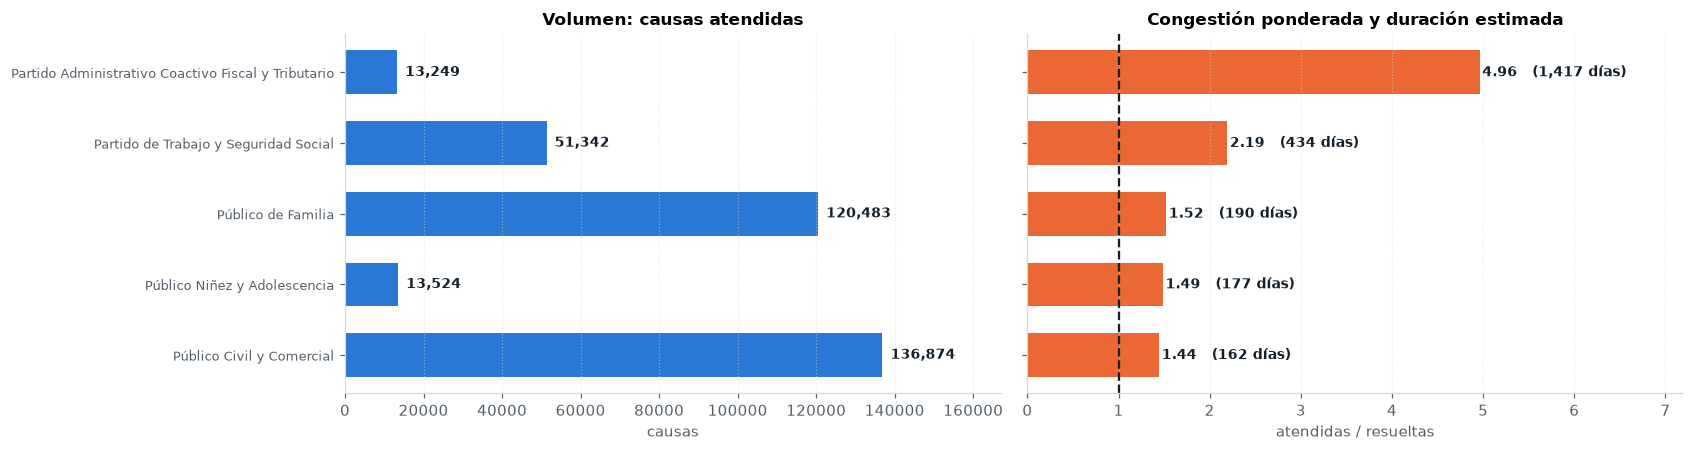

In [6]:
m = materias.sort_values("congestion_ponderada")
y = np.arange(len(m))
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.2))

axes[0].barh(y, m["atendidas"], color=AZUL, height=.62)
for i, v in enumerate(m["atendidas"]):
    axes[0].text(v + m["atendidas"].max() * .015, i, f"{int(v):,}", va="center",
                 fontsize=9, fontweight="bold", color=TINTA)
axes[0].set_yticks(y); axes[0].set_yticklabels(m["materia_homologada"], fontsize=8.5)
axes[0].set_xlim(0, m["atendidas"].max() * 1.22)
axes[0].set_title("Volumen: causas atendidas"); axes[0].set_xlabel("causas")
axes[0].grid(axis="y", visible=False)

axes[1].barh(y, m["congestion_ponderada"], color=NARANJA, height=.62)
axes[1].axvline(1.0, color=TINTA, lw=1.5, ls="--")
for i, (c, d) in enumerate(zip(m["congestion_ponderada"], m["duracion_dias_ponderada"])):
    axes[1].text(c + .03, i, f"{c:.2f}   ({d:,.0f} días)", va="center",
                 fontsize=9, fontweight="bold", color=TINTA)
axes[1].set_yticks(y); axes[1].set_yticklabels([])
axes[1].set_xlim(0, m["congestion_ponderada"].max() * 1.45)
axes[1].set_title("Congestión ponderada y duración estimada")
axes[1].set_xlabel("atendidas / resueltas")
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

Volumen y congestión no coinciden. La materia con más causas no es la más
congestionada: hay una que mueve poco volumen y acumula mucho.

## 3. Capital contra provincia

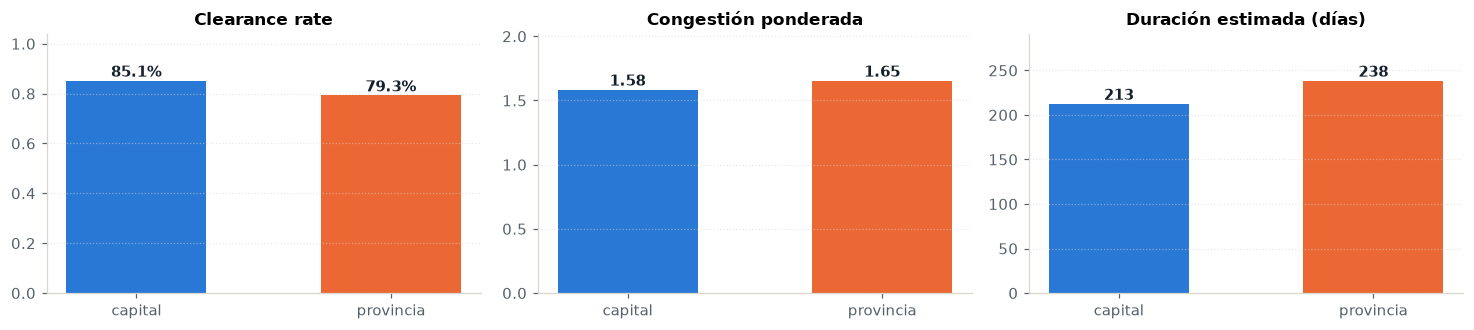

,ambito,total_procesos,ingresos_totales,nuevas_ingresadas,atendidas,resueltas,pendientes_fin,cr_mediana,congestion_mediana,duracion_dias_mediana,cr_ponderado,congestion_ponderada,duracion_dias_ponderada
0,capital,890,176734.0,141967,238306,150408,87688,0.855,1.529,183.593,0.851,1.584,212.795
1,provincia,765,74137.0,59488,97166,58789,38377,0.828,1.566,206.555,0.793,1.653,238.269


In [7]:
ambitos = proc.groupby("ambito").agg(
    total_procesos=("tipo_proceso", "count"),
    ingresos_totales=("ingresos_totales", "sum"),
    nuevas_ingresadas=("nuevas_ingresadas", "sum"),
    atendidas=("atendidas", "sum"),
    resueltas=("resueltas", "sum"),
    pendientes_fin=("pendientes_fin", "sum"),
    cr_mediana=("tasa_resolucion", "median"),
    congestion_mediana=("tasa_congestion", "median"),
    duracion_dias_mediana=("duracion_estimada_dias", "median"),
).reset_index()
ambitos["cr_ponderado"] = ambitos["resueltas"] / ambitos["ingresos_totales"].replace(0, np.nan)
ambitos["congestion_ponderada"] = ambitos["atendidas"] / ambitos["resueltas"].replace(0, np.nan)
ambitos["duracion_dias_ponderada"] = (ambitos["pendientes_fin"] / ambitos["resueltas"].replace(0, np.nan)) * 365

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.1))
for ax, (col, titulo, fmt) in zip(axes, [
        ("cr_ponderado", "Clearance rate", "{:.1%}"),
        ("congestion_ponderada", "Congestión ponderada", "{:.2f}"),
        ("duracion_dias_ponderada", "Duración estimada (días)", "{:,.0f}")]):
    vals = ambitos[col].astype(float).values
    ax.bar(ambitos["ambito"], vals, color=[AZUL, NARANJA], width=.55)
    for i, v in enumerate(vals):
        ax.text(i, v * 1.02, fmt.format(v), ha="center", fontsize=10,
                fontweight="bold", color=TINTA)
    ax.set_ylim(0, max(vals) * 1.22)
    ax.set_title(titulo)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

ambitos.round(3)

## 4. Mapa de calor: departamento × materia

Escala secuencial de un solo tono: más oscuro es más congestionado. Se usa la
tasa **winsorizada** porque la original tiene valores que se van al infinito y
aplastarían el resto de la escala.

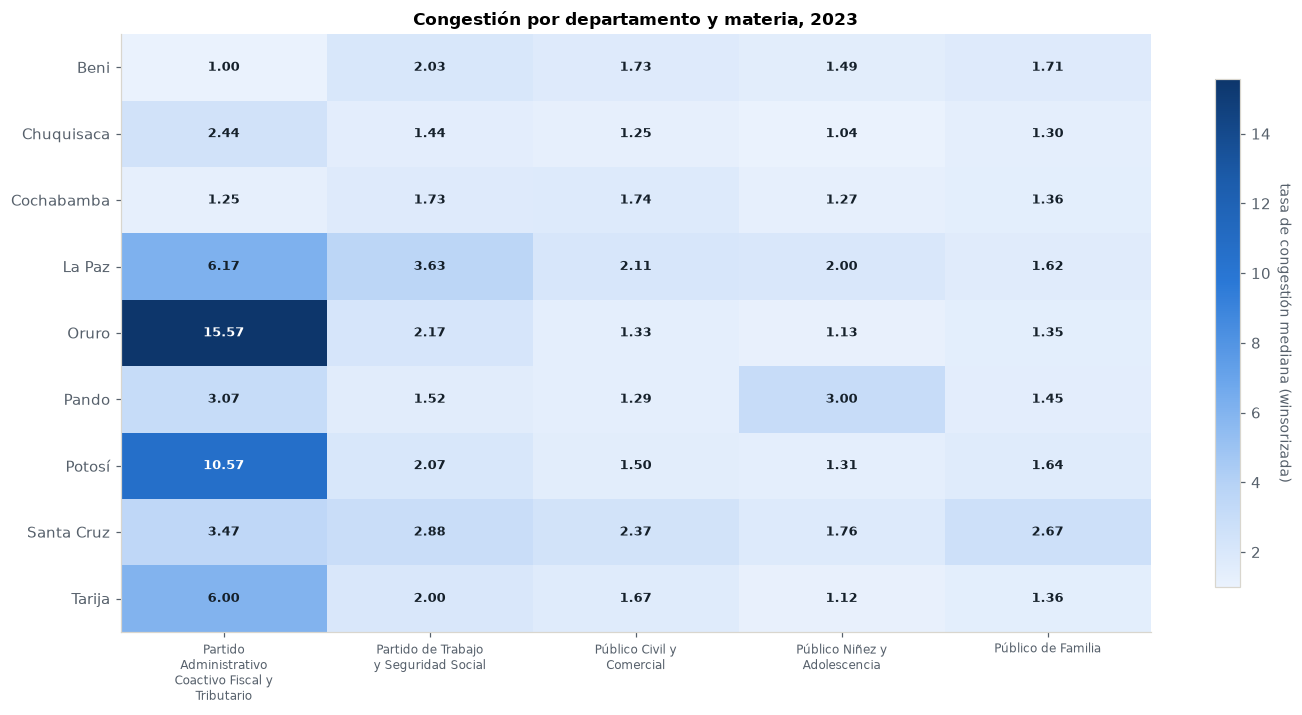

In [8]:
from matplotlib.colors import LinearSegmentedColormap
CMAP = LinearSegmentedColormap.from_list("azules", RAMPA_AZUL)

pivot = proc.pivot_table(index="departamento_derivado", columns="materia_homologada",
                         values="tasa_congestion_winsorizada", aggfunc="median")

fig, ax = plt.subplots(figsize=(13, 6.6))
im = ax.imshow(pivot.values, cmap=CMAP, aspect="auto")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels([envolver(c, 18) for c in pivot.columns], rotation=0, ha="center", fontsize=8)
ax.set_yticklabels(pivot.index, fontsize=9.5)

vmax = np.nanmax(pivot.values)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                    fontweight="bold", color="white" if v > vmax * .62 else TINTA)

cb = ax.figure.colorbar(im, ax=ax, shrink=.85)
cb.ax.set_ylabel("tasa de congestión mediana (winsorizada)", rotation=-90, va="bottom", fontsize=9)
ax.set_title("Congestión por departamento y materia, 2023")
ax.grid(False)
plt.tight_layout()
plt.savefig(OUT_FIG / "03_heatmap_congestion_departamento_materia.png")
plt.show()

## 5. Recursos contra carga

In [9]:
deptos = proc.groupby("departamento_derivado").agg(
    total_procesos=("tipo_proceso", "count"),
    ingresos_totales=("ingresos_totales", "sum"),
    nuevas_ingresadas=("nuevas_ingresadas", "sum"),
    atendidas=("atendidas", "sum"),
    resueltas=("resueltas", "sum"),
    pendientes_fin=("pendientes_fin", "sum"),
    personal_items=("personal_items_total", "first"),
    juzgados_publicados=("recurso_juzgados_publicados", "sum"),
    cr_mediana=("tasa_resolucion", "median"),
    congestion_mediana=("tasa_congestion", "median"),
    duracion_dias_mediana=("duracion_estimada_dias", "median"),
).reset_index()
deptos["cr_ponderado"] = deptos["resueltas"] / deptos["ingresos_totales"].replace(0, np.nan)
deptos["congestion_ponderada"] = deptos["atendidas"] / deptos["resueltas"].replace(0, np.nan)
deptos["duracion_dias_ponderada"] = (deptos["pendientes_fin"] / deptos["resueltas"].replace(0, np.nan)) * 365
deptos["causas_por_funcionario"] = deptos["atendidas"] / deptos["personal_items"].replace(0, np.nan)
deptos = deptos.sort_values("atendidas", ascending=False)
deptos.round(2)

,departamento_derivado,total_procesos,ingresos_totales,nuevas_ingresadas,atendidas,resueltas,pendientes_fin,personal_items,juzgados_publicados,cr_mediana,congestion_mediana,duracion_dias_mediana,cr_ponderado,congestion_ponderada,duracion_dias_ponderada,causas_por_funcionario
3,La Paz,263,67824.0,52948,98531,55457,43074,1560,21136,0.70,2.00,365.00,0.82,1.78,283.5,63.16
7,Santa Cruz,174,64486.0,48578,91497,50674,40823,1348,17686,0.62,2.33,484.66,0.79,1.81,294.04,67.88
2,Cochabamba,174,45081.0,38298,53222,39433,13789,1112,15672,0.89,1.50,181.14,0.87,1.35,127.63,47.86
6,Potosí,174,17905.0,14357,24607,15816,8791,594,9081,0.90,1.53,194.17,0.88,1.56,202.88,41.43
8,Tarija,174,15170.0,12575,19196,13238,5958,522,6972,0.93,1.42,152.08,0.87,1.45,164.27,36.77
4,Oruro,174,15522.0,13827,17425,13674,3541,470,6223,0.91,1.32,109.50,0.88,1.27,94.52,37.07
1,Chuquisaca,174,13471.0,11511,15117,11369,3748,565,8105,0.96,1.22,80.99,0.84,1.33,120.33,26.76
0,Beni,174,8872.0,7189,12081,7111,4970,413,5568,0.75,1.71,258.32,0.8,1.7,255.1,29.25
5,Pando,174,2540.0,2172,3796,2425,1371,182,2294,0.76,1.48,173.81,0.95,1.57,206.36,20.86


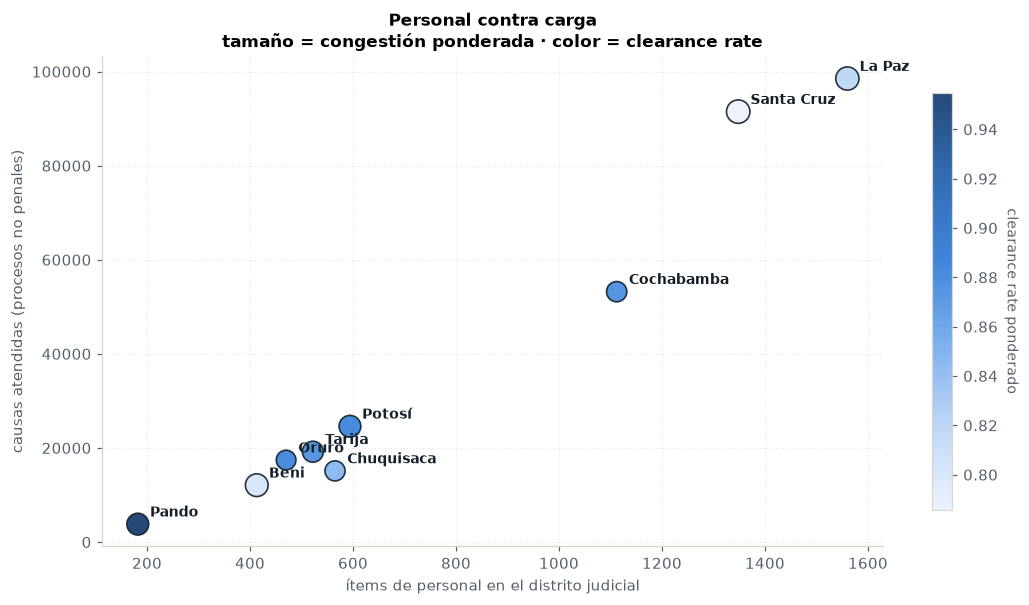

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.6))
sc = ax.scatter(deptos["personal_items"].astype(float), deptos["atendidas"].astype(float),
                s=deptos["congestion_ponderada"].astype(float) * 130,
                c=deptos["cr_ponderado"].astype(float), cmap=CMAP,
                alpha=.9, edgecolors=TINTA, linewidth=1.1, zorder=3)
for _, r in deptos.iterrows():
    ax.annotate(r["departamento_derivado"], (r["personal_items"], r["atendidas"]),
                xytext=(8, 5), textcoords="offset points", fontsize=9,
                fontweight="bold", color=TINTA)
ax.set_xlabel("ítems de personal en el distrito judicial")
ax.set_ylabel("causas atendidas (procesos no penales)")
ax.set_title("Personal contra carga\ntamaño = congestión ponderada · color = clearance rate")
cb = plt.colorbar(sc, ax=ax, shrink=.85)
cb.ax.set_ylabel("clearance rate ponderado", rotation=-90, va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_FIG / "04_dispersion_recursos_vs_resolucion.png")
plt.show()

> **Cuidado con `causas_por_funcionario`.** El numerador son solo las causas no
> penales de este análisis; el denominador es el personal **completo** del
> distrito, que también atiende materia penal. El ratio real es más alto. Sirve
> para comparar departamentos entre sí, no como carga absoluta.

## 6. Dónde está la mora acumulada

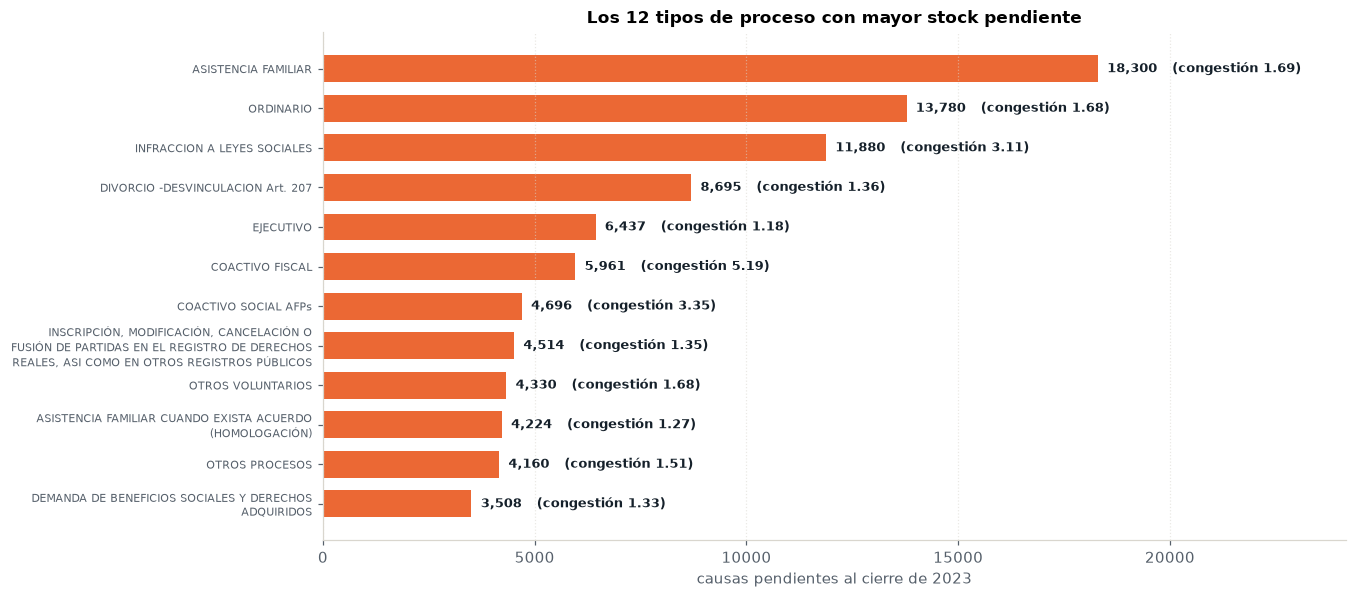

,materia_homologada,tipo_proceso,atendidas_total,resueltas_total,pendientes_total,duracion_media_dias,congestion_media,congestion_ponderada,duracion_ponderada_dias
66,Público de Familia,ASISTENCIA FAMILIAR,44644,26344,18300,273.17,1.75,1.69,253.55
32,Público Civil y Comercial,ORDINARIO,34177,20397,13780,372.43,2.02,1.68,246.59
11,Partido de Trabajo y Seguridad Social,INFRACCION A LEYES SOCIALES,17504,5624,11880,1209.04,4.31,3.11,771.02
78,Público de Familia,DIVORCIO -DESVINCULACION Art. 207,32934,24239,8695,195.78,1.54,1.36,130.93
25,Público Civil y Comercial,EJECUTIVO,42303,35866,6437,84.65,1.23,1.18,65.51
0,Partido Administrativo Coactivo Fiscal y Tribu...,COACTIVO FISCAL,7383,1422,5961,2404.05,7.59,5.19,1530.07
4,Partido de Trabajo y Seguridad Social,COACTIVO SOCIAL AFPs,6697,2001,4696,1103.35,4.02,3.35,856.59
28,Público Civil y Comercial,"INSCRIPCIÓN, MODIFICACIÓN, CANCELACIÓN O FUSIÓ...",17339,12825,4514,158.62,1.43,1.35,128.47
35,Público Civil y Comercial,OTROS VOLUNTARIOS,10661,6331,4330,250.98,1.69,1.68,249.64
67,Público de Familia,ASISTENCIA FAMILIAR CUANDO EXISTA ACUERDO (HOM...,19819,15595,4224,82.66,1.23,1.27,98.86


In [11]:
top_proc = proc.groupby(["materia_homologada", "tipo_proceso"]).agg(
    atendidas_total=("atendidas", "sum"),
    resueltas_total=("resueltas", "sum"),
    pendientes_total=("pendientes_fin", "sum"),
    duracion_media_dias=("duracion_estimada_dias", "mean"),
    congestion_media=("tasa_congestion", "mean"),
).reset_index()
top_proc["congestion_ponderada"] = top_proc["atendidas_total"] / top_proc["resueltas_total"].replace(0, np.nan)
top_proc["duracion_ponderada_dias"] = (top_proc["pendientes_total"] / top_proc["resueltas_total"].replace(0, np.nan)) * 365
top20 = top_proc.sort_values("pendientes_total", ascending=False).head(20)

t = top20.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(t)), t["pendientes_total"].astype(float), color=NARANJA, height=.68)
ax.set_yticks(range(len(t)))
ax.set_yticklabels([envolver(r.tipo_proceso, 46) for r in t.itertuples()], fontsize=7.5)
for i, (v, c) in enumerate(zip(t["pendientes_total"], t["congestion_ponderada"])):
    ax.text(v + t["pendientes_total"].max() * .012, i,
            f"{int(v):,}   (congestión {c:.2f})", va="center", fontsize=8.5,
            fontweight="bold", color=TINTA)
ax.set_xlim(0, t["pendientes_total"].max() * 1.32)
ax.set_xlabel("causas pendientes al cierre de 2023")
ax.set_title("Los 12 tipos de proceso con mayor stock pendiente")
ax.grid(axis="y", visible=False)
plt.show()

top20.round(2)

## 7. Trazabilidad del tratamiento: 87 → 115 columnas

Resumen de lo que hicieron los tres pasos de la capa analítica. Ningún
tratamiento sobrescribió ni eliminó nada.

In [12]:
base = pd.read_parquet(RAIZ_PROYECTO / "data/processed/analitico/dataset_analitico_interno.parquet")
ind = pd.read_parquet(RAIZ_PROYECTO / "data/curated/features/dataset_analitico_indicadores.parquet")

traza = pd.DataFrame([
    {"paso": "08 — integración interna", "columnas": len(base.columns),
     "agrega": "—", "filas": len(base)},
    {"paso": "09 — nulos y estados", "columnas": len(base.columns) + 1,
     "agrega": "estado_gestion", "filas": len(base)},
    {"paso": "10 — indicadores", "columnas": len(ind.columns),
     "agrega": f"{len(ind.columns) - len(base.columns) - 1} indicadores y flags", "filas": len(ind)},
    {"paso": "11 — outliers", "columnas": len(df.columns),
     "agrega": f"{len(df.columns) - len(ind.columns)} banderas, winsorizadas y log", "filas": len(df)},
])
print(f"columnas originales intactas en el dataset curado: "
      f"{df[list(base.columns)].equals(base[list(base.columns)])}")
print(f"filas en todos los pasos: {len(base):,} = {len(ind):,} = {len(df):,}")
traza

columnas originales intactas en el dataset curado: True
filas en todos los pasos: 1,997 = 1,997 = 1,997


,paso,columnas,agrega,filas
0,08 — integración interna,87,—,1997
1,09 — nulos y estados,88,estado_gestion,1997
2,10 — indicadores,100,12 indicadores y flags,1997
3,11 — outliers,115,"15 banderas, winsorizadas y log",1997


## 8. Artefactos y reporte

In [13]:
deptos.to_csv(OUT_TABLES / "resumen_congestion_departamental.csv", index=False, encoding="utf-8")
materias.to_csv(OUT_TABLES / "resumen_congestion_materia.csv", index=False, encoding="utf-8")
ambitos.to_csv(OUT_TABLES / "resumen_congestion_ambito.csv", index=False, encoding="utf-8")
top20.to_csv(OUT_TABLES / "top_procesos_congestionados.csv", index=False, encoding="utf-8")

# El generador del reporte vive en el script original; se reutiliza tal cual en
# vez de duplicar sus cien líneas de plantilla. Se importa AL FINAL porque el
# script fija el backend "Agg" de matplotlib al importarse, y eso apagaría los
# gráficos inline si se hiciera antes.
import importlib.util
spec = importlib.util.spec_from_file_location(
    "reporte_eda", RAIZ_PROYECTO / "src" / "analysis" / "12_reporte_eda.py")
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

ruta_reporte = OUT_DOCS / "reporte_eda_congestion_2023.md"
mod.generar_documento_reporte(deptos, materias, ambitos, top20, ruta_reporte, df)

print("escritos:")
for f in ["reports/tables/resumen_congestion_departamental.csv",
          "reports/tables/resumen_congestion_materia.csv",
          "reports/tables/resumen_congestion_ambito.csv",
          "reports/tables/top_procesos_congestionados.csv",
          "reports/figures/03_heatmap_congestion_departamento_materia.png",
          "reports/figures/04_dispersion_recursos_vs_resolucion.png",
          "docs/reporte_eda_congestion_2023.md"]:
    print("  " + f)

escritos:
  reports/tables/resumen_congestion_departamental.csv
  reports/tables/resumen_congestion_materia.csv
  reports/tables/resumen_congestion_ambito.csv
  reports/tables/top_procesos_congestionados.csv
  reports/figures/03_heatmap_congestion_departamento_materia.png
  reports/figures/04_dispersion_recursos_vs_resolucion.png
  docs/reporte_eda_congestion_2023.md


---

## Lo que este EDA no puede responder

- **No hay fuente externa.** Sin población del INE no hay tasas por cien mil
  habitantes ni comparación con el índice de CEJA.
- **`num_juzgados` es nominal**: un juzgado mixto cuenta una vez por cada materia
  que atiende, así que no es un denominador físico.
- **Esto mide celeridad, no calidad** de las decisiones judiciales.
- **La materia penal queda afuera**, y es aproximadamente la mitad del sistema.